#### This notebook aims at performing clustering on one of the quarters and expanding it to of ther quarters, fitting the same centroids for other quaters for comparable clusters.

In [2]:
# import some libraries into the notebook
# all these libraries are pre-installed in Cloud Pak for Data

import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
import sys
import pickle as pk

from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score, silhouette_samples

import seaborn as sns
import matplotlib.pyplot as plt
#from matplotlib.pyplot import figure
%matplotlib inline

In [3]:
# define a preprocessor function
# handle scaling and imputation

def preprocessor_sprint1(list_of_numerical_features):
    '''
    num_features is a python list of numerical features
    '''
    scaler = StandardScaler() # use robust or standard
    
    numerical_pipeline = make_pipeline(SimpleImputer(strategy='mean'), scaler)
    
    preprocessor = make_column_transformer((numerical_pipeline, list_of_numerical_features), remainder='drop')
    
    return preprocessor

# 1. Import data
Since from sprint one analysis we know that trends in data were similar for all the quarters of 2019 and 2020. Hence we can select any quater of 2019 for creating the cluster centroids and try to fit the other quarters to them. For our analysis we selected Q3 of 2019.
If the trend in data changes, change the data source in the next cell to retrain the clusters.

In [4]:
#df_sprint1 = pd.read_csv('/project_data/data_asset/revised_op_analysis_07012019_09302019.csv')
df_sprint1 = pd.read_csv('/project_data/data_asset/final_op_analysis_07012019_09302019.csv')
df_sprint1.head()

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,2,2,22.0,2019-08-26,2019-07-23,10531,35,1.0,11.0,0.057143,0.628571,0.333333,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,10.579864,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0
1,1,1,60.0,2019-07-12,2019-07-12,105316,1,1.0,60.0,1.000000,60.000000,0.052632,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,6.730443,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,9,390.0,2019-09-19,2019-07-11,105327,71,1.5,65.0,0.126761,5.492958,0.333333,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,6.529557,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2,2,32.0,2019-09-06,2019-07-17,105329,52,1.0,16.0,0.038462,0.615385,0.035714,0.0,0,0.0,0.0,0.0,1.0,0.0,0,0,0.0,0.0,4.505377,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2,6,180.0,2019-09-20,2019-07-08,10533,75,3.0,90.0,0.080000,2.400000,0.545455,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,11.682132,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0


In [5]:
df_sprint1.describe()

,Member Count,Count Script,Sum Dispensed Quantity,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
count,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.0,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000,13286.000000
mean,9.063902,17.967184,902.832903,117836.660093,53.396131,1.627068,69.752474,0.439538,17.222046,0.151559,0.045831,0.358422,0.000074,0.000669,0.025175,0.396728,0.096085,0.0,0.000828,0.000649,0.021600,21.536321,0.036403,0.002698,0.050021,0.000583,0.000010,0.218583,0.017790,0.001388
std,16.364043,46.479322,3289.042543,41725.954254,33.687678,0.919531,84.830565,0.599271,42.316096,0.204067,0.171720,2.047078,0.000642,0.017767,0.096869,0.383026,0.170143,0.0,0.028763,0.019284,0.091195,35.745566,0.167000,0.035612,0.143523,0.012590,0.000791,0.287577,0.081275,0.018082
min,1.000000,1.000000,0.360000,13.000000,1.000000,1.000000,0.360000,0.021739,0.035088,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,46.000000,107657.250000,20.000000,1.000000,16.500000,0.098120,2.309859,0.019231,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,5.876800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,6.000000,156.000000,121878.000000,65.000000,1.250000,40.000000,0.195122,6.143718,0.075188,0.000000,0.000000,0.000000,0.000000,0.000000,0.300000,0.000000,0.0,0.000000,0.000000,0.000000,10.437657,0.000000,0.000000,0.000000,0.000000,0.000000,0.111111,0.000000,0.000000
75%,10.000000,16.000000,600.000000,144647.250000,84.000000,2.000000,90.000000,0.738043,16.721995,0.197322,0.000000,0.000000,0.000000,0.000000,0.000000,0.750000,0.160000,0.0,0.000000,0.000000,0.000000,21.047096,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000
max,301.000000,1603.000000,143680.500000,176132.000000,92.000000,13.000000,1470.000000,17.423913,1561.744565,1.000000,1.000000,67.000000,0.034483,1.000000,1.000000,1.000000,0.860000,0.0,1.000000,1.000000,1.000000,983.908528,1.000000,1.000000,1.000000,1.000000,0.083333,1.000000,1.000000,1.000000


In [6]:
df_sprint1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13286 entries, 0 to 13285
Data columns (total 32 columns):
Member Count              13286 non-null int64
Count Script              13286 non-null int64
Sum Dispensed Quantity    13286 non-null float64
Max Dispense Date         13286 non-null object
Min Dispense Date         13286 non-null object
PRSCRB_PROV_LOC_ID        13286 non-null int64
Total Days                13286 non-null int64
PR2                       13286 non-null float64
PR1                       13286 non-null float64
PR4                       13286 non-null float64
PR3                       13286 non-null float64
PR5                       13286 non-null float64
PR6                       13286 non-null float64
PR7                       13286 non-null int64
PR8                       13286 non-null float64
PR9                       13286 non-null float64
PR10                      13286 non-null float64
PR11                      13286 non-null float64
PR13                 

In [7]:
df_sprint1.shape

(13286, 32)

# 2. Pre-process Data

In [8]:
# make lists of indicies and features for preprocessing pipeline
# We have dropped PRs that have very sparse values or have potential to influence data and cause data leakage (with respect to the risk scores)

to_drop = []
index = ['PRSCRB_PROV_LOC_ID', 'Max Dispense Date', 'Min Dispense Date', 'Total Days', 'PR11', 'PR1', 'PR13', 'PR15', 'PR18']
features = [c for c in df_sprint1.columns if c not in index or to_drop]
num_features = df_sprint1[features].select_dtypes('number').columns.tolist()

In [9]:
# redefine columns

features = [c for c in df_sprint1.columns if c not in to_drop+index]
num_features = df_sprint1[features].select_dtypes('number').columns.tolist()

In [10]:
num_features

['Member Count',
 'Count Script',
 'Sum Dispensed Quantity',
 'PR2',
 'PR4',
 'PR3',
 'PR5',
 'PR6',
 'PR7',
 'PR8',
 'PR9',
 'PR10',
 'PR19',
 'PR21',
 'PR22',
 'PR23',
 'PR24',
 'PR25',
 'PR26',
 'PR27',
 'PR28',
 'PR29',
 'PR30']

In [11]:
# call the preprocessor
# see that the preprocessor is working
preprocessor_sprint1_regen = preprocessor_sprint1(num_features)

tmp = preprocessor_sprint1_regen.transformers[0][1].fit_transform(df_sprint1[num_features])
df_sprint1_processed = pd.DataFrame(data=tmp, columns=[c for c in num_features if df_sprint1[c].isna().all()==False], index=df_sprint1.index)
df_sprint1_processed.head()

,Member Count,Count Script,Sum Dispensed Quantity,PR2,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,-0.431688,-0.343546,-0.267818,-0.681968,-0.638124,-0.392146,0.890790,-0.266907,-0.175096,-0.114718,-0.037663,-0.259898,-0.033668,-0.236864,-0.306524,-0.217989,-0.075769,-0.348536,-0.046347,-0.012668,0.978617,-0.218898,-0.076756
1,-0.492800,-0.365062,-0.256264,-0.681968,0.935275,1.010953,-0.484800,-0.266907,-0.175096,-0.114718,-0.037663,-0.259898,-0.033668,-0.236864,-0.414217,-0.217989,-0.075769,-0.348536,-0.046347,-0.012668,-0.760112,-0.218898,-0.076756
2,-0.187241,-0.192936,-0.155928,-0.138193,-0.521949,-0.277188,0.890790,-0.266907,-0.175096,-0.114718,-0.037663,-0.259898,-0.033668,-0.236864,-0.419837,-0.217989,-0.075769,-0.348536,-0.046347,-0.012668,-0.760112,-0.218898,-0.076756
3,-0.431688,-0.343546,-0.264778,-0.681968,-0.669299,-0.392458,-0.567704,-0.266907,-0.175096,-0.114718,-0.037663,-0.259898,-0.033668,-0.236864,-0.476467,-0.217989,-0.075769,-0.348536,-0.046347,-0.012668,-0.760112,-0.218898,-0.076756
4,-0.431688,-0.257483,-0.219778,1.493135,-0.599981,-0.350283,1.930298,-0.266907,-0.175096,-0.114718,-0.037663,-0.259898,-0.033668,-0.236864,-0.275686,-0.217989,-0.075769,-0.348536,-0.046347,-0.012668,0.978617,-0.218898,-0.076756


# 3. PCA - KMeans Cluster Analysis
Our intention is to find the optimal number of principal components we would be using for clustering. Once we have out optimal PCA transformation on the training aka Q3 data, we can save the transform so that it can be applied to all the other quarters transforming them in the same space as the training data. Post this we need to find the optimal number of clusters with reasonable error, degree of separation and size.
<br> If you are not retraining your clusters and PCA and the cluster model is saved, retrive the saved models by uncommenting the next cell and spik the rest of the section.

In [12]:
# reload the pca pickle file
pca = pk.load(open("/project_data/data_asset/pca_q3.pkl",'rb'))
kmeans = pk.load(open("/project_data/data_asset/kmeans_q3.pkl", "rb"))

In [13]:
pca = PCA()
X_pca = pca.fit(df_sprint1_processed)

Text(0, 0.5, 'cumulative explained variance')

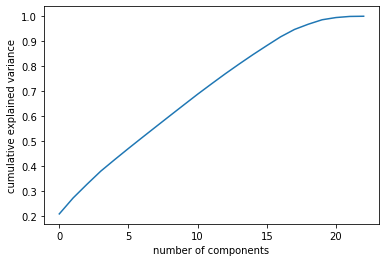

In [14]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')

In [15]:
pca = PCA(n_components = 0.50)
X_pca = pca.fit_transform(df_sprint1_processed)
print(pca.n_components_)

7


In [16]:
n_pcs= pca.n_components_ # get number of component
# get the index of the most important feature on EACH component
most_important = [np.abs(pca.components_[i]).argmax() for i in range(n_pcs)]
initial_feature_names = df_sprint1_processed.columns
# get the most important feature names
most_important_names = [initial_feature_names[most_important[i]] for i in range(n_pcs)]

In [17]:
print(most_important_names)

['Sum Dispensed Quantity', 'PR25', 'PR5', 'PR28', 'PR23', 'PR29', 'PR8']


In [18]:
var = pca.explained_variance_ratio_
print(var)

[0.20930056 0.06383208 0.0546665  0.05265982 0.04587386 0.04489907
 0.04396363]


Text(0, 0.5, 'Explained Variance Ratio')

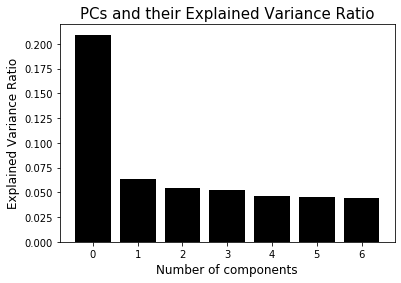

In [19]:
#Plot explained variance ratio for each PC
plt.bar([i for i, _ in enumerate(var)],var,color='black')
plt.title('PCs and their Explained Variance Ratio', fontsize=15)
plt.xlabel('Number of components',fontsize=12)
plt.ylabel('Explained Variance Ratio',fontsize=12)

In [20]:
#Cumulative Variance explained by each PC
cum_var = np.cumsum(np.round(pca.explained_variance_ratio_, decimals=4)*100)
print(cum_var)

[20.93 27.31 32.78 38.05 42.64 47.13 51.53]


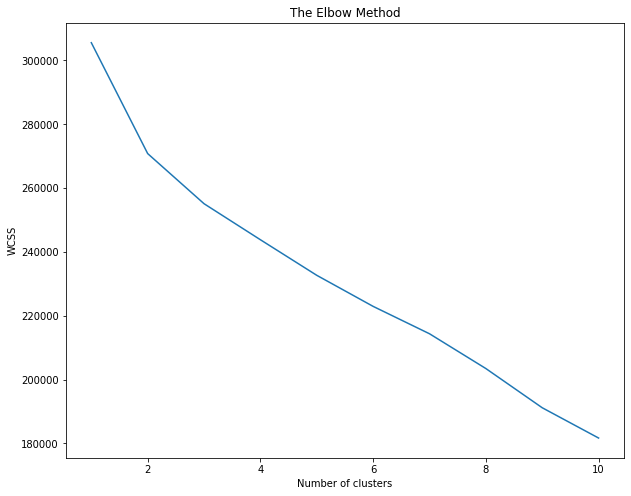

In [21]:
# find the appropriate cluster number
plt.figure(figsize=(10, 8))
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(df_sprint1_processed)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

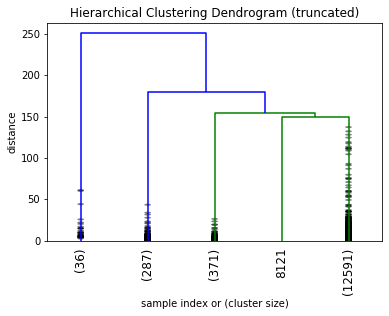

In [22]:
# Hierarchical clustering for the same dataset
# creating a dataset for hierarchical clustering
dataset2_standardized = df_sprint1_processed
# needed imports
from scipy.cluster.hierarchy import dendrogram, linkage

# some setting for this notebook to actually show the graphs inline
# you probably won't need this
%matplotlib inline
np.set_printoptions(precision=6, suppress=True)  # suppress scientific float notation
#creating the linkage matrix
H_cluster = linkage(dataset2_standardized,'ward')
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('sample index or (cluster size)')
plt.ylabel('distance')
dendrogram(
    H_cluster,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=5,  # show only the last p merged clusters
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,  # to get a distribution impression in truncated branches
)
plt.show()

Text(0, 0.5, 'Cumulative Explained Variance Ratio')

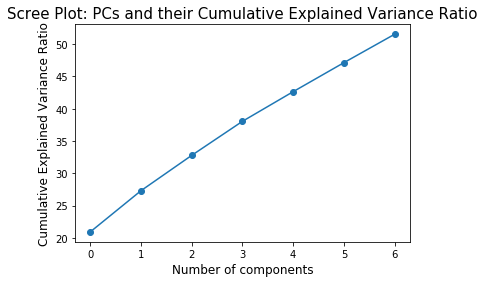

In [23]:
# Scree Plot
plt.plot(cum_var, marker='o')
plt.title('Scree Plot: PCs and their Cumulative Explained Variance Ratio',fontsize=15)
plt.xlabel('Number of components',fontsize=12)
plt.ylabel('Cumulative Explained Variance Ratio',fontsize=12)

In [24]:
#Fitting PCA data into K-Means model with 5 clusters
km_5=KMeans(n_clusters=5,random_state=12345)
km_5.fit(df_sprint1_processed)
print(km_5.cluster_centers_)

[[-0.47243  -0.343546 -0.26493  -0.047563  0.297891 -0.184586 -0.472985
  -0.266907 -0.093676 -0.114718 -0.037663 -0.259898 43.181194  0.676966
   0.993743 -0.217989 -0.075769  0.232112 -0.046347 -0.012668  1.558193
  -0.218898 -0.076756]
 [-0.281501 -0.205771 -0.149978  0.193816 -0.071661 -0.060908  1.038383
   1.131857 -0.007509  0.220076 -0.01657   0.608488 -0.015844  0.720341
   0.159038 -0.020268 -0.066759  1.178826 -0.046347 -0.012668  0.22034
  -0.040327  0.297112]
 [ 2.461647  2.214496  1.779696  1.141488  1.587394  1.630909 -0.056076
  -0.15401   0.955709  0.266494  0.012564  0.227778  0.013694  0.119376
  -0.084241 -0.113364  1.09981   0.110183  0.493683 -0.012668  0.175521
   0.047558  0.134721]
 [-0.143113 -0.15165  -0.138311 -0.115315 -0.127357 -0.135978 -0.187469
  -0.193673 -0.112099 -0.063255  0.001932 -0.12699  -0.022252 -0.139698
  -0.024199  0.011819 -0.056447 -0.222774 -0.022496 -0.002768 -0.053306
   0.004098 -0.064543]
 [ 9.016465 11.282133 12.095283  2.036943  9.

In [25]:
pd.Series(km_5.labels_).value_counts()

3    10649
1     1919
2      664
4       48
0        6
dtype: int64

In [26]:
from sklearn import metrics
metrics.silhouette_score(df_sprint1_processed, km_5.labels_) #Score with 5 labels is decent, let's see if this improves.

0.3707537285676748

In [27]:
# calculate SC for K=2 through K=10
k_range = range(2, 10)
scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=12345)
    km.fit(df_sprint1_processed)
    scores.append(metrics.silhouette_score(df_sprint1_processed, km.labels_))

In [28]:
print(scores)

[0.7545642797417793, 0.45514838958478615, 0.4255871786746051, 0.3707537285676748, 0.4128407526433563, 0.22070840641006856, 0.4218807289613235, 0.4150687909055488]


In [29]:
#Evaluating quality of the clusters
sse,db,slc = {}, {}, {}
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000,random_state=12345).fit(df_sprint1_processed)
    if k == 4: labels = kmeans.labels_
    clusters = kmeans.labels_
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
    db[k] = davies_bouldin_score(df_sprint1_processed,clusters)
    slc[k] = silhouette_score(df_sprint1_processed,clusters)

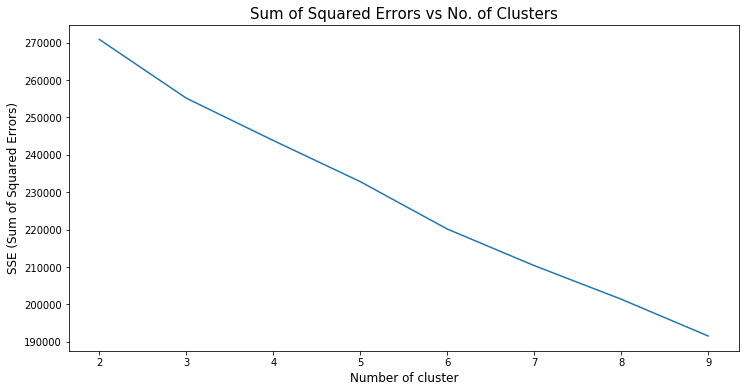

In [30]:
#Plotting SSE
plt.figure(figsize=(12,6))
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of cluster", fontsize=12)
plt.ylabel("SSE (Sum of Squared Errors)", fontsize=12)
plt.title("Sum of Squared Errors vs No. of Clusters", fontsize=15)
plt.show()

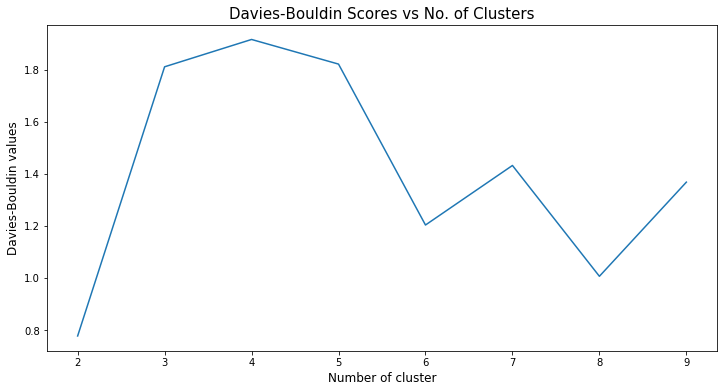

In [31]:
#Plotting Davies-Bouldin Scores
plt.figure(figsize=(12,6))
plt.plot(list(db.keys()), list(db.values()))
plt.xlabel("Number of cluster", fontsize=12)
plt.ylabel("Davies-Bouldin values", fontsize=12)
plt.title("Davies-Bouldin Scores vs No. of Clusters", fontsize=15)
plt.show()

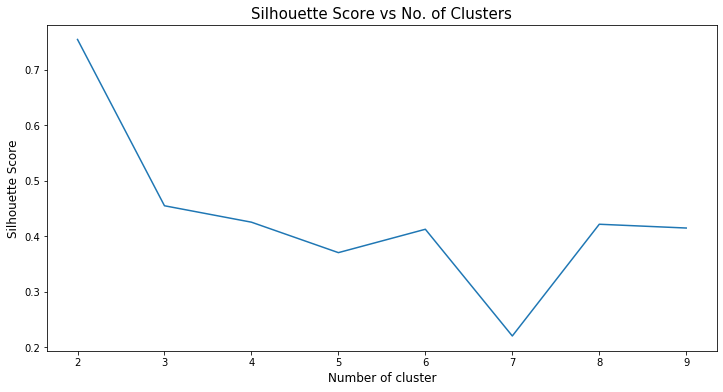

In [32]:
plt.figure(figsize=(12,6))
plt.plot(list(slc.keys()), list(slc.values()))
plt.xlabel("Number of cluster", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Silhouette Score vs No. of Clusters", fontsize=15)
plt.show()

### Since the cluster seems to have a decent silhouette score with small error factor for 5 and 6 clusters, we can use either 5 or 6 final clusters.

In [33]:
df_sprint1_processed2 = df_sprint1_processed

In [34]:
# start with the maximum number of components
# this helps to show us all the variance per component

pca = PCA(n_components=df_sprint1_processed2.shape[1]) #Initialize PCA with components = number variables in preprocessed dataframe
tmp_pca = pca.fit_transform(df_sprint1_processed2) #Call fit_transform method to apply PCA

# now we have the same result as we had in Sprint 1
# this can be read as, "First component explains 35.5% of variance in the data, second component explains 17.8% of variance in the data, ..."

pca.explained_variance_ratio_

array([0.209301, 0.063832, 0.054666, 0.05266 , 0.045874, 0.044899,
       0.043964, 0.043562, 0.043418, 0.043136, 0.042857, 0.041246,
       0.040532, 0.038869, 0.037717, 0.036029, 0.035252, 0.029378,
       0.020992, 0.017771, 0.008852, 0.004435, 0.000758])

In [35]:
# the variable `num_components_tokeep` can be changed to include more or less components for the clustering
# using the variable makes it easier for us to change if we want
# We notice the varience for component stays stagnant after 5 for a while before rapidly reducing. Hence we select 5 components for the final analysis.
num_components_tokeep = 5
df_for_clustering = pd.DataFrame(data=tmp_pca[:,:num_components_tokeep], columns=[(f'Comp {c}') for c in range(1,num_components_tokeep+1)], index=df_sprint1_processed2.index)
df_for_clustering.head()

,Comp 1,Comp 2,Comp 3,Comp 4,Comp 5
0,-0.996243,-0.287136,-0.135774,-0.732524,-0.455923
1,0.035468,-0.964652,0.250403,0.346103,-0.466188
2,-0.638582,-0.479772,-0.334253,0.581385,-0.077126
3,-1.069836,-0.655752,0.413868,0.600732,-0.360576
4,-0.541001,0.603012,-0.409091,-0.022237,0.103625


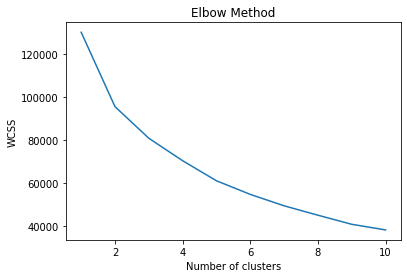

In [36]:
# make the Elbow Plot to see what is the ideal number of clusters
wcss = [] # within cluster sum of squares (sum of squared distance to cluster centroid)
for i in range(1, 11):
    #run k-means for clusters 1 - 11
    kmeans = KMeans(n_clusters=i, init='random', max_iter=300, n_init=10, random_state=12) 
    kmeans.fit(df_for_clustering)
    wcss.append(kmeans.inertia_) #inertia = wcss
plt.plot(range(1, 11), wcss)
#The elbow point indicates the number of clusters at which we've explained much of the variation in the
# reduced dataset without separating the data too much (with each observation being assigned to their own cluster 
# being maximum number of clusters and pretty pointless)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [37]:
# IMO, 6 is the ideal number of clusters
number_of_clusters = 6

kmeans = KMeans(n_clusters=number_of_clusters, random_state=12) # make the clustering
kmeans.fit(df_for_clustering) # fit the clustering to the data
y_kmeans = kmeans.predict(df_for_clustering) # predict to get the labels

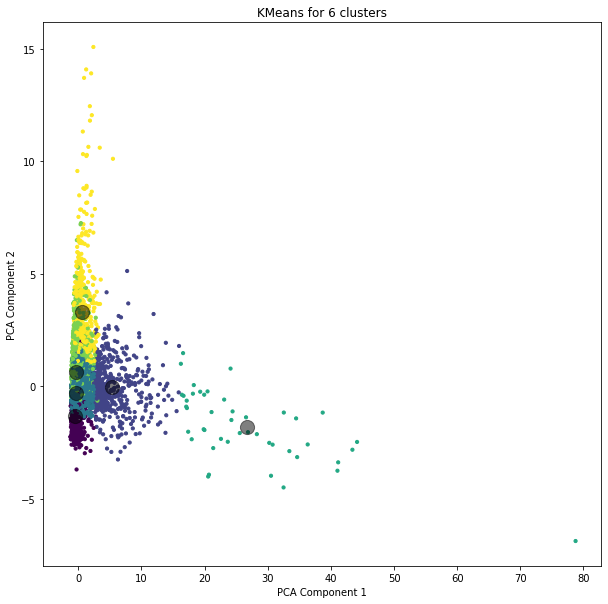

In [38]:
plt.figure(figsize=(10,10))
plt.scatter(df_for_clustering.iloc[:, 0], df_for_clustering.iloc[:, 1], c=y_kmeans, s=10, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.title('KMeans for 6 clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show();

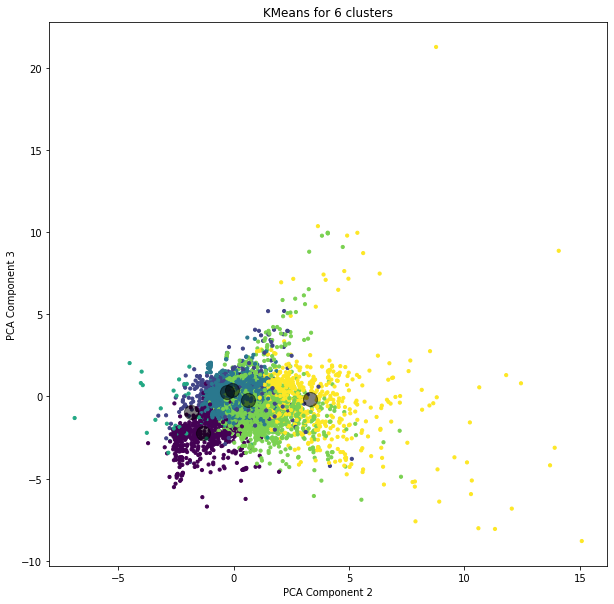

In [39]:
plt.figure(figsize=(10,10))
plt.scatter(df_for_clustering.iloc[:, 1], df_for_clustering.iloc[:, 2], c=y_kmeans, s=10, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)
plt.title('KMeans for 6 clusters')
plt.xlabel('PCA Component 2')
plt.ylabel('PCA Component 3')
plt.show();

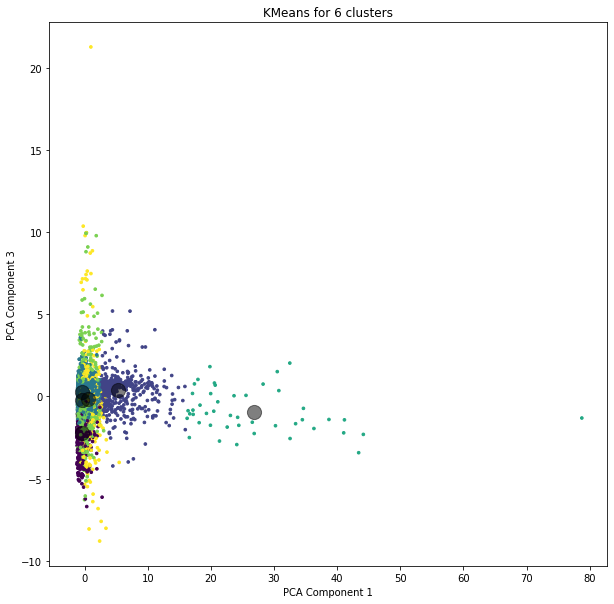

In [40]:
plt.figure(figsize=(10,10))
plt.scatter(df_for_clustering.iloc[:, 0], df_for_clustering.iloc[:, 2], c=y_kmeans, s=7, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 2], c='black', s=200, alpha=0.5)
plt.title('KMeans for 6 clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 3')

plt.show();

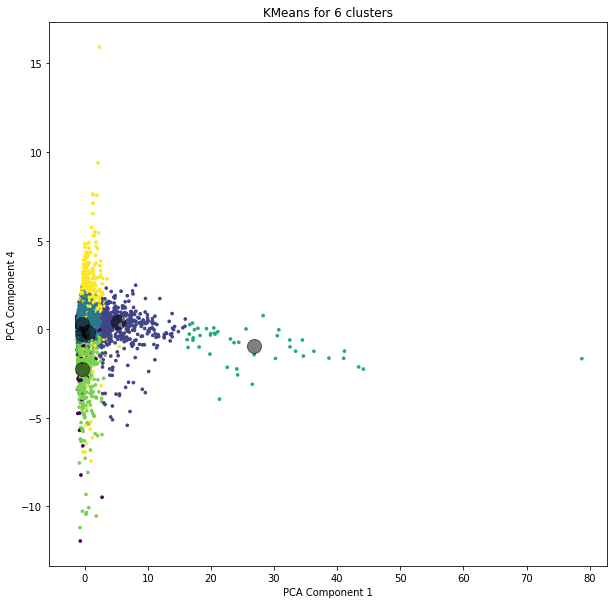

In [41]:
plt.figure(figsize=(10,10))
plt.scatter(df_for_clustering.iloc[:, 0], df_for_clustering.iloc[:, 3], c=y_kmeans, s=7, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 2], c='black', s=200, alpha=0.5)
plt.title('KMeans for 6 clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 4')

plt.show();

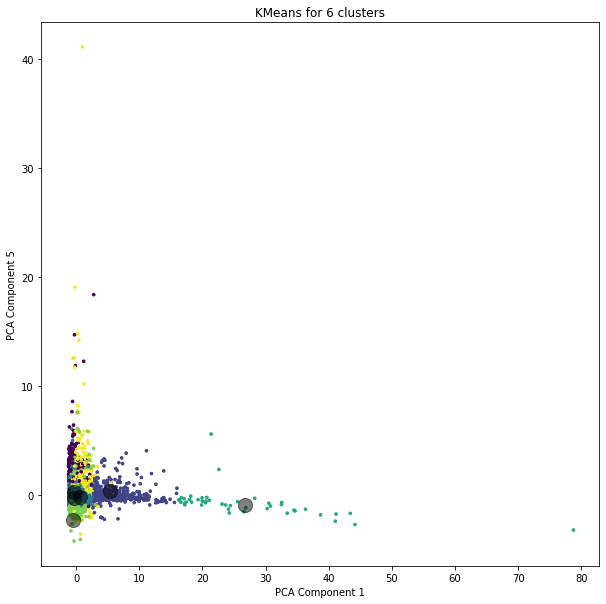

In [42]:
plt.figure(figsize=(10,10))
plt.scatter(df_for_clustering.iloc[:, 0], df_for_clustering.iloc[:, 4], c=y_kmeans, s=7, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 2], c='black', s=200, alpha=0.5)
plt.title('KMeans for 6 clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 5')

plt.show();

In [43]:
# calculate silhouette score of this clustering algorithm
sil_score = round(silhouette_score(df_for_clustering, y_kmeans), 3)
print(f'Silhouette score for 6 clusters is {sil_score}')

Silhouette score for 6 clusters is 0.34


### Hence we will be using 6 clusters for segregation with 5 principal components. now we can save the models

In [44]:
#Save PCA and KMean as pickles.
#If you are retraining the models, uncomment this cell

pk.dump(pca, open("/project_data/data_asset/pca_q3.pkl","wb"))
pk.dump(kmeans, open("/project_data/data_asset/kmeans_q3.pkl", "wb"))

# 4. Evaluate Q3 2019 clusters with the risk scores

In [45]:
#If you are not retraining the data, you do not need to run this section.
#Section 3 needs to be run to get clusters for Q3 since this is the training data.

df_for_clustering = pd.DataFrame(data=tmp_pca[:,:num_components_tokeep], columns=[(f'Comp {c}') for c in range(1,num_components_tokeep+1)], index=df_sprint1_processed.index)
y_kmeans = kmeans.predict(df_for_clustering)
df_sprint1['Cluster_label'] = pd.Series(y_kmeans, index=df_sprint1.index)
df_sprint1.head()

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30,Cluster_label
0,2,2,22.0,2019-08-26,2019-07-23,10531,35,1.0,11.0,0.057143,0.628571,0.333333,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,10.579864,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,4
1,1,1,60.0,2019-07-12,2019-07-12,105316,1,1.0,60.0,1.000000,60.000000,0.052632,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,6.730443,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,6,9,390.0,2019-09-19,2019-07-11,105327,71,1.5,65.0,0.126761,5.492958,0.333333,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,6.529557,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2,2,32.0,2019-09-06,2019-07-17,105329,52,1.0,16.0,0.038462,0.615385,0.035714,0.0,0,0.0,0.0,0.0,1.0,0.0,0,0,0.0,0.0,4.505377,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2,6,180.0,2019-09-20,2019-07-08,10533,75,3.0,90.0,0.080000,2.400000,0.545455,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,11.682132,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,2


In [46]:
pd.Series(y_kmeans).value_counts()

2    8455
4    2805
0     827
5     628
1     526
3      45
dtype: int64

In [50]:
riskiest_cluster = pd.Series(y_kmeans).value_counts().idxmin()
pd.Series(y_kmeans).value_counts().idxmin()

3

### Add Risk Scores to the clustered results for profiling the clusters

In [51]:
riskscore_df = pd.read_csv('/project_data/data_asset/2019q3_riskscore.csv')
riskscore_df.head()

,PRSCRB_PROV_LOC_ID,Risk_Score
0,10531,1.678160
1,105316,2.956597
2,105327,1.806869
3,105329,0.191069
4,10533,4.057747


In [55]:
#If we consider the risk score to be 50+ for bad and medium risk actors, we need to find the clusters for the following actors.
bad_actors = list(riskscore_df[riskscore_df.Risk_Score > 50].PRSCRB_PROV_LOC_ID)
bad_actors

[107410, 148485, 139433, 165027, 165594, 16638, 17522, 4457, 170094]

In [56]:
q3_2019 = pd.merge(df_sprint1, riskscore_df, on='PRSCRB_PROV_LOC_ID')
q3_2019.groupby('Cluster_label').describe().reset_index()
#q3_2019.groupby('Cluster_label').describe().unstack(1).reset_index()

Cluster_label Member Count                                              \
                       count        mean        std   min     25%    50%   
0             0        827.0    5.083434   8.093076   1.0    1.00    2.0   
1             1        526.0   55.233840  29.657866   1.0   36.25   50.0   
2             2       8455.0    7.262093   8.001960   1.0    2.00    4.0   
3             3         45.0  160.777778  50.756052  74.0  123.00  149.0   
4             4       2805.0    5.419608   6.727610   1.0    1.00    3.0   
5             5        628.0    5.299363   5.096160   1.0    2.00    3.0   

                Count Script                                               \
     75%    max        count        mean         std    min    25%    50%   
0    5.0   83.0        827.0    6.425635   10.870366    1.0    1.0    3.0   
1   68.0  184.0        526.0  137.665399   68.825122    1.0   93.0  118.0   
2   10.0   70.0       8455.0   12.288941   15.119472    1.0    2.0    6.0   
3  192.0  301.0         45.0  554.844444  235.196722  304.0  394.0  472.0   
4    7.0   66.0       2805.0    7.336898   10.665191    1.0    2.0    4.0   
5    7.0   34.0        628.0   18.367834   18.863990    1.0    5.0   11.0   

                  Sum Dispensed Quantity                              \
      75%     max                  count          mean           std   
0    6.00    85.0                  827.0    215.330982    471.583252   
1  170.75   401.0                  526.0   7874.161913   5015.123727   
2   16.00    97.0                 8455.0    524.947565    815.501085   
3  665.00  1603.0                   45.0  41811.119444  20956.213336   
4    8.00    97.0                 2805.0    234.374875    451.529835   
5   26.00    98.0                  628.0   1111.140924   1300.251321   

                                                    PRSCRB_PROV_LOC_ID  \
        min       25%      50%        75%       max              count   
0      1.00     20.00     55.0    180.000    4651.0              827.0   
1    270.00   4778.25   6523.5   9954.125   27500.0              526.0   
2      0.36     56.00    180.0    600.000    8043.0             8455.0   
3  19599.00  28621.00  35041.0  53652.000  143680.5               45.0   
4      1.00     30.00     84.0    216.000    4548.0             2805.0   
5      1.00    188.50    655.0   1550.250    8370.0              628.0   

                                                                       \
            mean           std     min       25%       50%        75%   
0  120736.918984  41047.540711   139.0  109606.0  124282.0  148271.00   
1  118097.794677  39645.170736   220.0  107093.0  122853.0  141601.25   
2  117451.940627  41897.111238    13.0  107097.0  121754.0  144400.50   
3  124676.000000  46595.358973  1303.0  113084.0  132740.0  157144.00   
4  119217.490553  41029.487653   176.0  108724.0  121734.0  146271.00   
5  112320.628981  44156.215687   247.0  105817.5  120181.5  138358.25   

            Total Days                                                      \
        max      count       mean        std   min   25%   50%   75%   max   
0  176089.0      827.0  34.503023  33.285156   1.0   1.0  27.0  68.0  92.0   
1  175099.0      526.0  87.543726  16.710447   1.0  90.0  92.0  92.0  92.0   
2  176132.0     8455.0  55.261857  32.755177   1.0  28.0  67.0  84.0  92.0   
3  171287.0       45.0  91.755556   1.069315  86.0  92.0  92.0  92.0  92.0   
4  175852.0     2805.0  43.604635  33.059906   1.0   2.0  48.0  75.0  92.0   
5  175530.0      628.0  65.541401  28.635083   1.0  52.0  78.0  87.0  92.0   

      PR2                                                              \
    count      mean       std       min       25%       50%       75%   
0   827.0  1.184519  0.401719  1.000000  1.000000  1.000000  1.166667   
1   526.0  2.638929  0.945829  1.000000  2.082850  2.559412  3.085714   
2  8455.0  1.573258  0.691640  1.000000  1.000000  1.333333  2.000000   
3    45.0  3.462297  0.748838  

### Check which clusters the bad actors belong to

In [57]:
#q3 2019
#Q3 Current list of Bad actors from Risk Scoring Notebook - [107410, 148485, 139433, 165027, 165594, 16638, 17522, 4457, 170094]
#Use updated list of high risk actors from the risk scoring notebook (2019q3_riskscore.csv) when retraining the data or when a different dataset is being evaluated.
print(df_sprint1[df_sprint1.PRSCRB_PROV_LOC_ID.isin(bad_actors)][["PRSCRB_PROV_LOC_ID","Cluster_label"]])

       PRSCRB_PROV_LOC_ID  Cluster_label
4151               107410              3
8121               148485              0
8851               139433              3
10123              165027              3
10209              165594              3
10303               16638              3
11858               17522              3
12656                4457              3
13026              170094              3


In [58]:
#Assess all the Provider ids in the riskiest_cluster:
print(list(df_sprint1[df_sprint1.Cluster_label == riskiest_cluster].PRSCRB_PROV_LOC_ID))

[100365, 101378, 105200, 109494, 113084, 115182, 117265, 111813, 107410, 122407, 122721, 122949, 124315, 129086, 1303, 119298, 121068, 132740, 144019, 147313, 139250, 139433, 132023, 157756, 159447, 163881, 164940, 165027, 165594, 166049, 16638, 167357, 149990, 153504, 153890, 154518, 155049, 157070, 157144, 157335, 17522, 2755, 4457, 170094, 171287]


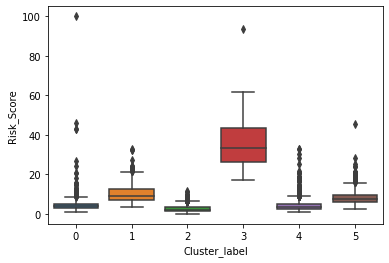

In [59]:
sns.boxplot(x="Cluster_label", y="Risk_Score", data=q3_2019)

In [60]:
#Save the clusters with risk scores
q3_2019.to_csv('/project_data/data_asset/2019q3_clusteredrisk.csv', index=False)

# 5. Experiment with other Quarters now

You can rerun or switch data sources this section if you want to evaluate more quarters. For now we have evaluated Q1, Q2, Q4 OF 2019 and Q1, Q2 OF 2020.
<br> The 'clusteredrisk' files saved in this section combines the clusters with the risk scores and is being used by the final dashboard. These are saved per quarter.



##### Retrive information about the riskiest cluster from the training dataset which in out case is 2019 Q3
##### To run any quarter information in section 5 you will need the 'riskiest_cluster' variable set. Hence you will need to run the following cell to run anything in this section.

In [64]:
train_df = pd.read_csv('/project_data/data_asset/2019q3_clusteredrisk.csv')
riskiest_cluster = train_df.Cluster_label.value_counts().idxmin()
riskiest_cluster

3

## Q1 2019

In [125]:
df_quarter1 = pd.read_csv('/project_data/data_asset/final_op_analysis_01012019_03312019.csv')
df_quarter1.head()

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,17,71,5138.0,2019-03-29,2019-01-02,122635,87,4.176471,302.235294,0.816092,59.057471,0.112426,0.058824,2,0.000000,0.0,0.117647,0.070423,0.40,0,0,0.0,0.117647,3.845711,0.021277,0.0,0.117647,0.0,0.0,0.176471,0,0.0
1,66,218,19647.0,2019-03-31,2019-01-02,137238,89,3.303030,297.681818,2.449438,220.752809,0.168421,0.015152,9,0.000686,0.0,0.045455,0.238532,0.21,0,0,0.0,0.045455,5.635131,0.000000,0.0,0.181818,0.0,0.0,0.151515,0,0.0
2,4,25,997.0,2019-03-26,2019-01-01,118005,85,6.250000,249.250000,0.294118,11.729412,0.017986,0.000000,1,0.000000,0.0,0.500000,0.000000,0.40,0,0,0.0,0.000000,12.411909,0.000000,0.0,0.250000,0.0,0.0,0.250000,0,0.0
3,7,18,1771.0,2019-03-31,2019-01-09,25176,82,2.571429,253.000000,0.219512,21.597561,0.050847,0.000000,0,0.000000,0.0,0.142857,0.611111,0.28,0,0,0.0,0.000000,17.807810,0.000000,0.0,0.000000,0.0,0.0,0.142857,0,0.0
4,4,9,678.0,2019-03-29,2019-01-03,114682,86,2.250000,169.500000,0.104651,7.883721,0.076923,0.250000,0,0.000000,0.0,0.000000,0.000000,0.00,0,0,0.0,0.000000,4.560072,0.000000,0.0,0.000000,0.0,0.0,0.250000,0,0.0


In [126]:
tmp = preprocessor_sprint1_regen.transformers[0][1].fit_transform(df_quarter1[num_features])
df_quarter1_processed = pd.DataFrame(data=tmp, columns=[c for c in num_features if df_quarter1[c].isna().all()==False], index=df_quarter1.index)
df_quarter1_processed.head()

,Member Count,Count Script,Sum Dispensed Quantity,PR2,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,0.427194,1.018411,1.209533,2.790708,0.563728,0.969188,-0.203831,0.093473,0.812395,-0.062877,-0.035368,0.825790,-0.065166,1.082859,-0.463188,-0.079558,-0.059603,0.498062,-0.076997,-0.017072,-0.132110,0.0,-0.070847
1,3.266877,3.933933,5.437461,1.828096,3.114631,4.800045,0.064605,-0.169611,4.336105,0.428080,-0.035368,0.138295,-0.065166,0.263560,-0.415847,-0.215277,-0.059603,0.963222,-0.076997,-0.017072,-0.220751,0.0,-0.070847
2,-0.326191,0.106071,0.002844,5.075930,-0.251473,-0.152099,-0.656572,-0.260885,0.309008,-0.062877,-0.035368,4.466964,-0.065166,-0.252296,-0.236559,-0.215277,-0.059603,1.457455,-0.076997,-0.017072,0.129066,0.0,-0.070847
3,-0.152333,-0.032763,0.228388,1.021803,-0.367989,0.081695,-0.499034,-0.260885,-0.194379,-0.062877,-0.035368,1.065867,-0.065166,-0.252296,-0.093804,-0.215277,-0.059603,-0.354732,-0.076997,-0.017072,-0.251504,0.0,-0.070847
4,-0.326191,-0.211265,-0.090112,0.667559,-0.547375,-0.243211,-0.374030,1.245137,-0.194379,-0.062877,-0.035368,-0.294572,-0.065166,-0.252296,-0.444289,-0.215277,-0.059603,-0.354732,-0.076997,-0.017072,0.129066,0.0,-0.070847


In [127]:
df_quarter1_tfd = pca.transform(df_quarter1_processed)

In [128]:
num_components_tokeep = 5
df_quarter1_tfd_for_clustering = pd.DataFrame(data=df_quarter1_tfd[:,:num_components_tokeep], 
                                              columns=[(f'Comp {c}') for c in range(1,num_components_tokeep+1)], 
                                              index=df_quarter1_processed.index)
df_quarter1_tfd_for_clustering.head()

,Comp 1,Comp 2,Comp 3,Comp 4,Comp 5
0,2.556719,1.854241,0.312163,1.254629,0.329976
1,10.386354,-0.087934,-0.079085,0.416189,-0.494880
2,0.974773,4.528521,1.270567,2.949430,1.797923
3,0.029840,0.568221,0.753466,1.061174,0.376988
4,-0.586232,0.380831,0.161322,0.505159,-0.470842


In [129]:
test_labels = kmeans.predict(df_quarter1_tfd_for_clustering)
pd.Series(test_labels).value_counts()

2    8603
4    2773
0     811
5     666
1     553
3      45
dtype: int64

In [130]:
df_quarter1['Cluster_label'] = pd.Series(test_labels, index=df_quarter1.index)
print(list(df_quarter1[df_quarter1.Cluster_label == riskiest_cluster].PRSCRB_PROV_LOC_ID))

[165027, 122949, 157070, 137712, 1303, 156800, 107410, 154518, 147313, 108876, 121068, 9374, 156748, 103845, 139433, 103610, 150142, 144019, 105200, 163881, 119298, 165518, 155049, 16638, 115182, 17522, 109494, 157335, 141476, 153504, 143839, 153890, 4457, 129086, 113084, 132740, 122407, 154674, 149990, 22216, 111813, 132023, 165594, 100365, 109666]


In [131]:
list(set(list(df_quarter1[df_quarter1.Cluster_label == riskiest_cluster].PRSCRB_PROV_LOC_ID)) & set(list(df_sprint1[df_sprint1.Cluster_label == riskiest_cluster].PRSCRB_PROV_LOC_ID)))
#31 are common in Q1 and Q3

[119298,
 132740,
 100365,
 157070,
 107410,
 144019,
 154518,
 157335,
 1303,
 153504,
 153890,
 165027,
 122407,
 139433,
 163881,
 155049,
 109494,
 132023,
 113084,
 129086,
 111813,
 122949,
 165594,
 149990,
 4457,
 121068,
 115182,
 105200,
 147313,
 17522,
 16638]

In [132]:
#Risk Profile
riskscore_df = pd.read_csv('/project_data/data_asset/2019q1_riskscore.csv')
riskscore_df.head()

,PRSCRB_PROV_LOC_ID,Risk_Score
0,122635,10.317008
1,137238,17.938831
2,118005,10.414828
3,25176,5.421807
4,114682,3.200099


In [133]:
#If we consider the risk score to be 50+ for bad and medium risk actors, we need to find the clusters for the following actors.
bad_actors = list(riskscore_df[riskscore_df.Risk_Score > 50].PRSCRB_PROV_LOC_ID)
bad_actors

[165027,
 156800,
 107410,
 152853,
 139433,
 16638,
 17522,
 121269,
 111598,
 112675,
 149181]

In [135]:
q1_2019 = pd.merge(df_quarter1, riskscore_df, on='PRSCRB_PROV_LOC_ID')
q1_2019.groupby('Cluster_label').describe().reset_index()

Cluster_label Member Count                                             \
                       count        mean        std   min    25%    50%   
0             0        811.0    5.514180   8.603372   1.0    1.0    2.0   
1             1        553.0   59.947559  32.454469   1.0   38.0   53.0   
2             2       8603.0    7.516796   8.305926   1.0    2.0    4.0   
3             3         45.0  159.022222  47.554031  64.0  119.0  161.0   
4             4       2773.0    5.927876   7.269587   1.0    1.0    3.0   
5             5        666.0    5.450450   5.204808   1.0    2.0    4.0   

                Count Script                                               \
     75%    max        count        mean         std    min    25%    50%   
0    6.0   85.0        811.0    6.680641   10.667030    1.0    1.0    3.0   
1   72.0  194.0        553.0  154.745027   84.587801    1.0  100.0  129.0   
2   10.0   71.0       8603.0   12.979658   16.105599    1.0    2.0    7.0   
3  182.0  287.0         45.0  584.488889  209.846656  324.0  452.0  557.0   
4    7.0   69.0       2773.0    8.218175   11.728054    1.0    2.0    4.0   
5    7.0   28.0        666.0   18.905405   20.191826    1.0    5.0   11.0   

                 Sum Dispensed Quantity                                       \
     75%     max                  count          mean           std      min   
0    7.0    88.0                  811.0    230.417879    493.781379      0.8   
1  184.0   561.0                  553.0   8634.252550   5366.683693    150.0   
2   17.0   100.0                 8603.0    565.560386    876.983103      0.5   
3  689.0  1521.0                   45.0  43510.788889  19431.846003  20138.0   
4    9.0    97.0                 2773.0    271.750361    515.083663      1.0   
5   27.0   120.0                  666.0   1112.131832   1350.303543      1.0   

                                        PRSCRB_PROV_LOC_ID                 \
       25%      50%       75%       max              count           mean   
0     20.0     65.0    195.00    4910.0              811.0  115267.959309   
1   5219.0   6994.0  10948.00   27362.0              553.0  115944.685353   
2     60.0    189.0    648.00    7552.5             8603.0  114673.275834   
3  31749.0  40584.0  50866.00  138235.0               45.0  118959.066667   
4     36.0     93.0    266.00    5429.0             2773.0  116892.974396   
5    203.5    613.5   1482.75    9099.0              666.0  111830.752252   

                                                                 Total Days  \
            std     min        25%       50%       75%       max      count   
0  40891.254585   252.0  108120.50  121506.0  139225.0  170111.0      811.0   
1  38491.521958   220.0  107182.00  122553.0  137727.0  170367.0      553.0   
2  41443.186604     9.0  106190.00  120491.0  139904.5  170962.0     8603.0   
3  46922.152989  1303.0  108876.00  132023.0  153890.0  165594.0       45.0   
4  39969.906989    45.0  108211.00  120815.0  140143.0  170445.0     2773.0   
5  43597.292608   247.0  106187.25  120451.0  138984.0  170200.0      666.0   

                                                          PR2            \
        mean        std   min   25%   50%   75%   max   count      mean   
0  37.056720  32.840155   1.0   1.0  35.0  71.0  89.0   811.0  1.162595   
1  85.104882  13.182245   1.0  87.0  88.0  89.0  90.0   553.0  2.709899   
2  54.108567  31.518971   1.0  29.0  66.0  81.0  90.0  8603.0  1.584505   
3  89.400000   0.653661  88.0  89.0  89.0  90.0  90.0    45.0  3.728877   
4  45.096286  31.620502   1.0   8.0  52.0  74.0  90.0  2773.0  1.303876   
5  63.187688  27.719528   1.0  54.0  75.0  85.0  90.0   666.0  3.394652   

                                                                   PR1  \
        std       min       25%       50%       75%        max   count   
0  0.367791  1.000000  1.000000  1.000000  1.125000   4.000000   811.0   
1  0.906589  1.000000  2.186047  2.636364  3.142857   8.942308   553.0

In [136]:
#Which cluster do the risk score based bad actors belong to
print(q1_2019[q1_2019.PRSCRB_PROV_LOC_ID.isin(bad_actors)][["PRSCRB_PROV_LOC_ID","Cluster_label","Risk_Score"]])

       PRSCRB_PROV_LOC_ID  Cluster_label  Risk_Score
6                  165027              3   53.565219
50                 156800              3   54.221793
54                 107410              3   77.041835
1602               152853              5   78.552556
3294               139433              3   61.819008
5051                16638              3  100.000000
5065                17522              3   64.144826
7312               121269              0   76.100664
7866               111598              5   50.241109
7970               112675              0   50.956820
12010              149181              0   69.996136


In [138]:
#Least risk actors identified in riskiest cluster
q1_2019[(q1_2019.Cluster_label == riskiest_cluster) & (q1_2019.Risk_Score < 20)][["PRSCRB_PROV_LOC_ID","Cluster_label","Risk_Score"]]

,PRSCRB_PROV_LOC_ID,Cluster_label,Risk_Score
5081,109494,3,18.132803
5144,141476,3,16.261023


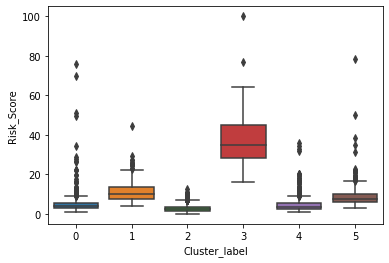

In [139]:
sns.boxplot(x="Cluster_label", y="Risk_Score", data=q1_2019)

In [140]:
#Save the clusters with risk scores
q1_2019.to_csv('/project_data/data_asset/2019q1_clusteredrisk.csv', index=False)

## Q2 2019

In [141]:
df_quarter2 = pd.read_csv('/project_data/data_asset/final_op_analysis_04012019_06302019.csv')
tmp = preprocessor_sprint1_regen.transformers[0][1].fit_transform(df_quarter2[num_features])
df_quarter2_processed = pd.DataFrame(data=tmp, columns=[c for c in num_features if df_quarter2[c].isna().all()==False], index=df_quarter2.index)
df_quarter2_processed.head()

,Member Count,Count Script,Sum Dispensed Quantity,PR2,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,3.523264,3.048959,2.879840,0.911584,2.242780,2.424984,-0.445382,0.001336,2.248811,-0.116609,-0.038766,0.326983,-0.046334,0.439779,-0.455077,-0.22311,-0.0764,0.080425,-0.054871,-0.014417,0.039345,-0.081178,-0.076226
1,-0.386323,-0.307557,-0.266417,-0.333724,-0.579224,-0.395831,-0.670790,-0.267375,-0.184982,-0.116609,-0.038766,3.067836,-0.046334,-0.244292,-0.500994,-0.22311,-0.0764,-0.358649,-0.054871,-0.014417,0.413090,-0.081178,-0.076226
2,0.234247,0.112007,0.137232,0.220867,-0.255031,-0.015561,-0.102891,-0.267375,-0.184982,-0.116609,-0.038766,-0.282095,-0.046334,-0.244292,-0.467152,-0.22311,-0.0764,-0.358649,-0.054871,-0.014417,-0.219401,-0.081178,-0.076226
3,-0.262209,-0.265601,-0.229125,-0.477917,-0.571217,-0.356915,-0.746704,-0.267375,-0.184982,-0.116609,-0.038766,1.727863,-0.046334,-0.244292,-0.428697,-0.22311,-0.0764,-0.358649,-0.054871,-0.014417,-0.761536,-0.081178,-0.076226
4,-0.510437,-0.370492,-0.273875,-0.694208,0.921474,0.308387,-0.746704,-0.267375,-0.184982,-0.116609,-0.038766,-0.282095,-0.046334,-0.244292,-0.458136,-0.22311,-0.0764,-0.358649,-0.054871,-0.014417,2.762343,-0.081178,-0.076226


In [142]:
df_quarter2_tfd = pca.transform(df_quarter2_processed)
df_quarter2_tfd_for_clustering = pd.DataFrame(data=df_quarter2_tfd[:,:num_components_tokeep], 
                                              columns=[(f'Comp {c}') for c in range(1,num_components_tokeep+1)], 
                                              index=df_quarter2_processed.index)
df_quarter2_tfd_for_clustering.head()

,Comp 1,Comp 2,Comp 3,Comp 4,Comp 5
0,6.733021,-0.283380,0.522478,0.253390,-0.451095
1,-0.745614,1.100618,0.932985,0.738541,0.393194
2,0.016857,-0.360048,0.439503,0.507372,-0.235890
3,-0.765481,0.213897,0.669596,1.100825,0.230933
4,-0.225608,-0.205272,1.087168,-1.756734,-1.092018


In [143]:
test_labels = kmeans.predict(df_quarter2_tfd_for_clustering)
pd.Series(test_labels).value_counts()

2    8483
4    2842
0     855
5     670
1     551
3      48
dtype: int64

In [144]:
df_quarter2['Cluster_label'] = pd.Series(test_labels, index=df_quarter2.index)
print(list(df_quarter2[df_quarter2.Cluster_label == riskiest_cluster].PRSCRB_PROV_LOC_ID))

[105200, 100365, 103610, 103845, 111813, 113084, 115182, 107410, 107547, 108876, 109494, 121068, 122407, 122949, 124315, 119298, 139433, 144019, 129086, 1303, 132023, 132740, 153504, 153890, 154674, 155049, 156748, 156800, 157070, 157144, 163881, 164940, 165027, 157335, 147313, 149990, 150142, 3791, 4457, 165518, 165594, 166049, 16638, 167357, 170094, 17522, 22216, 2755]


In [145]:
list((set(list(df_quarter1[df_quarter1.Cluster_label == riskiest_cluster].PRSCRB_PROV_LOC_ID)) & set(list(df_sprint1[df_sprint1.Cluster_label == riskiest_cluster].PRSCRB_PROV_LOC_ID))) 
     & set(list(df_quarter2[df_quarter2.Cluster_label == riskiest_cluster].PRSCRB_PROV_LOC_ID)))
#30 are common in Q1, Q2 and Q3

[119298,
 132740,
 100365,
 157070,
 107410,
 144019,
 157335,
 1303,
 153504,
 153890,
 165027,
 122407,
 139433,
 163881,
 155049,
 109494,
 132023,
 113084,
 129086,
 111813,
 122949,
 165594,
 149990,
 4457,
 121068,
 115182,
 105200,
 147313,
 17522,
 16638]

In [146]:
#Risk Profile
riskscore_df = pd.read_csv('/project_data/data_asset/2019q2_riskscore.csv')
q2_2019 = pd.merge(df_quarter2, riskscore_df, on='PRSCRB_PROV_LOC_ID')
q2_2019.groupby('Cluster_label').describe().reset_index()

Cluster_label Member Count                                              \
                       count        mean        std   min     25%    50%   
0             0        855.0    5.483041   8.997495   1.0    1.00    2.0   
1             1        551.0   54.598911  27.085533   1.0   37.00   50.0   
2             2       8483.0    7.285276   8.015824   1.0    2.00    4.0   
3             3         48.0  153.229167  45.956612  65.0  117.75  149.5   
4             4       2842.0    5.710063   6.962794   1.0    1.00    3.0   
5             5        670.0    5.843284   5.631237   1.0    2.00    4.0   

                 Count Script                                               \
      75%    max        count        mean         std    min    25%    50%   
0    6.00   85.0        855.0    6.843275   11.981103    1.0    1.0    3.0   
1   66.00  177.0        551.0  141.381125   71.044390    1.0   94.0  123.0   
2   10.00   66.0       8483.0   12.438053   15.319609    1.0    2.0    6.0   
3  180.25  276.0         48.0  549.583333  227.767783  242.0  377.0  516.0   
4    7.00   70.0       2842.0    7.754750   10.885181    1.0    2.0    4.0   
5    8.00   33.0        670.0   19.829851   20.478820    1.0    5.0   12.0   

                  Sum Dispensed Quantity                                       \
      75%     max                  count          mean           std      min   
0    7.00    97.0                  855.0    233.272398    550.060383      1.0   
1  171.50   442.0                  551.0   8166.323363   5193.237617    183.0   
2   16.00   104.0                 8483.0    539.655929    826.644107      0.5   
3  655.25  1538.0                   48.0  41454.104167  19359.552848  16021.0   
4    9.00   104.0                 2842.0    241.730823    448.506091      1.0   
5   27.00   112.0                  670.0   1188.012687   1370.842984      4.0   

                                        PRSCRB_PROV_LOC_ID                 \
       25%      50%       75%       max              count           mean   
0     20.0     60.0    189.00    6102.0              855.0  118624.845614   
1   4958.0   6810.0  10334.00   28182.0              551.0  118236.811252   
2     59.5    180.0    635.00    6906.0             8483.0  115495.869386   
3  29979.0  35981.0  47706.50  135412.0               48.0  119178.437500   
4     30.0     88.0    235.00    4616.0             2842.0  117927.461999   
5    202.5    672.0   1623.25    8678.0              670.0  109779.573134   

                                                                  Total Days  \
            std     min        25%       50%        75%       max      count   
0  38757.007173   139.0  109526.50  122355.0  140371.50  173267.0      855.0   
1  38557.324707   220.0  107215.00  123960.0  140830.50  172895.0      551.0   
2  41771.871874    13.0  106514.50  120825.0  140913.00  173212.0     8483.0   
3  50467.501331  1303.0  107512.75  130554.5  156761.00  170094.0       48.0   
4  40348.278096     9.0  108082.00  121745.5  142325.25  172933.0     2842.0   
5  45422.991870   267.0  104867.00  117939.0  136491.00  171451.0      670.0   

                                                          PR2            \
        mean        std   min   25%   50%   75%   max   count      mean   
0  36.671345  33.302929   1.0   1.0  36.0  69.0  91.0   855.0  1.165835   
1  87.159710  12.792181   1.0  88.0  89.0  91.0  91.0   551.0  2.719344   
2  55.232936  32.127773   1.0  29.0  68.0  83.0  91.0  8483.0  1.585999   
3  89.625000   5.803979  52.0  90.0  91.0  91.0  91.0    48.0  3.599289   
4  44.045391  32.468809   1.0   4.0  49.0  75.0  91.0  2842.0  1.285544   
5  66.740299  26.811271   1.0  59.0  78.0  86.0  91.0   670.0  3.442910   

                                                                   PR1  \
        std       min       25%       50%       75%        max   count   
0  0.399639  1.000000  1.000000  1.000000  1.100000   5.400000   855.0   
1  0.910727  1.000000  2.184524  2.620

In [147]:
#If we consider the risk score to be 50+ for bad and medium risk actors, we need to find the clusters for the following actors.
bad_actors = list(riskscore_df[riskscore_df.Risk_Score > 50].PRSCRB_PROV_LOC_ID)
bad_actors

[111813, 107410, 110160, 139433, 156800, 165027, 149990, 16638, 17522, 2755]

In [149]:
#Which cluster do the risk score based bad actors belong to
print(q2_2019[q2_2019.PRSCRB_PROV_LOC_ID.isin(bad_actors)][["PRSCRB_PROV_LOC_ID","Cluster_label","Risk_Score"]])

       PRSCRB_PROV_LOC_ID  Cluster_label  Risk_Score
1930               111813              3   55.237079
3254               107410              3   95.817114
4111               110160              1   76.604742
7189               139433              3   58.659310
9871               156800              3   52.980418
10243              165027              3   60.708021
11315              149990              3   50.395422
12242               16638              3  100.000000
12846               17522              3   68.639703
13418                2755              3   65.645996


In [150]:
#Least risk actors identified in riskiest cluster
q2_2019[(q2_2019.Cluster_label == riskiest_cluster) & (q2_2019.Risk_Score < 20)][["PRSCRB_PROV_LOC_ID","Cluster_label","Risk_Score"]]

,PRSCRB_PROV_LOC_ID,Cluster_label,Risk_Score
3898,109494,3,18.263276
12201,166049,3,15.014430


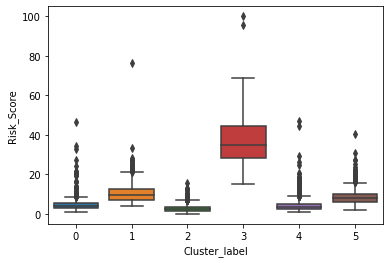

In [151]:
sns.boxplot(x="Cluster_label", y="Risk_Score", data=q2_2019)

In [152]:
#Save the clusters with risk scores
q2_2019.to_csv('/project_data/data_asset/2019q2_clusteredrisk.csv', index=False)

## Q4

In [153]:
df_quarter4 = pd.read_csv('/project_data/data_asset/final_op_analysis_10012019_12312019.csv')
tmp = preprocessor_sprint1_regen.transformers[0][1].fit_transform(df_quarter4[num_features])
df_quarter4_processed = pd.DataFrame(data=tmp, columns=[c for c in num_features if df_quarter4[c].isna().all()==False], index=df_quarter4.index)
df_quarter4_processed.head()

,Member Count,Count Script,Sum Dispensed Quantity,PR2,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,-0.481941,-0.359018,-0.271530,-0.677356,0.888926,0.055985,-0.740064,-0.259495,-0.177731,-0.116266,-0.035005,-0.248827,-0.054764,-0.233900,-0.330284,-0.207114,-0.070842,-0.352054,-0.06812,-0.012668,-0.741685,-0.364240,-0.06679
1,-0.363099,-0.317026,-0.264379,-0.677356,-0.680604,-0.408234,-0.038078,-0.259495,-0.177731,-0.116266,-0.035005,-0.248827,-0.054764,-0.233900,0.292773,-0.207114,-0.070842,-0.352054,-0.06812,-0.012668,2.706273,-0.364240,-0.06679
2,-0.363099,-0.317026,-0.260648,-0.677356,-0.650213,-0.396756,-0.038078,-0.259495,-0.177731,-0.116266,-0.035005,-0.248827,-0.054764,3.444975,0.989559,-0.207114,-0.070842,-0.352054,-0.06812,-0.012668,-0.741685,-0.364240,-0.06679
3,-0.065994,0.102890,0.046859,1.396202,-0.286683,-0.120697,-0.322846,0.483916,0.345842,-0.116266,-0.035005,-0.248827,-0.054764,-0.233900,-0.308058,-0.207114,-0.070842,-0.352054,-0.06812,-0.012668,0.120304,-0.364240,-0.06679
4,-0.422520,-0.317026,-0.271219,-0.124407,-0.663413,-0.412562,-0.740064,-0.259495,-0.177731,-0.116266,-0.035005,4.686694,-0.054764,-0.233900,-0.298573,-0.207114,-0.070842,-0.352054,-0.06812,-0.012668,-0.741685,2.273243,-0.06679


In [154]:
df_quarter4_tfd = pca.transform(df_quarter4_processed)
df_quarter4_tfd_for_clustering = pd.DataFrame(data=df_quarter4_tfd[:,:num_components_tokeep], 
                                              columns=[(f'Comp {c}') for c in range(1,num_components_tokeep+1)], 
                                              index=df_quarter4_processed.index)
df_quarter4_tfd_for_clustering.head()

,Comp 1,Comp 2,Comp 3,Comp 4,Comp 5
0,-0.363284,-0.893976,0.390832,0.384237,-0.450447
1,-0.985954,0.056311,0.579248,-1.879081,-0.716032
2,-0.905681,0.785981,-0.724884,-0.665037,0.056069
3,0.177821,0.425100,0.405092,0.730773,-0.244167
4,-0.680038,1.620844,1.127975,1.770108,1.689364


In [155]:
test_labels = kmeans.predict(df_quarter4_tfd_for_clustering)
pd.Series(test_labels).value_counts()

2    8718
4    2728
0     729
5     625
1     541
3      48
dtype: int64

In [156]:
df_quarter4['Cluster_label'] = pd.Series(test_labels, index=df_quarter4.index)
print(list(df_quarter4[df_quarter4.Cluster_label == riskiest_cluster].PRSCRB_PROV_LOC_ID))

[103278, 103845, 10505, 105077, 105200, 100365, 100841, 101378, 107410, 108113, 117265, 113084, 115182, 116654, 12692, 129086, 1303, 119298, 122721, 132023, 132740, 137712, 139433, 144019, 147313, 16638, 167357, 169127, 170094, 171287, 153504, 153890, 154518, 155049, 156875, 157070, 157144, 157335, 157756, 163881, 164940, 165027, 165594, 166049, 175099, 17522, 2755, 4457]


In [157]:
list((set(list(df_quarter1[df_quarter1.Cluster_label == riskiest_cluster].PRSCRB_PROV_LOC_ID)) & set(list(df_sprint1[df_sprint1.Cluster_label == riskiest_cluster].PRSCRB_PROV_LOC_ID))) 
     & (set(list(df_quarter2[df_quarter2.Cluster_label == riskiest_cluster].PRSCRB_PROV_LOC_ID)) & set(list(df_quarter4[df_quarter4.Cluster_label == riskiest_cluster].PRSCRB_PROV_LOC_ID))))
#24 are common in Q1, Q2, Q4 and Q3

[119298,
 132740,
 100365,
 157070,
 107410,
 144019,
 157335,
 1303,
 153504,
 153890,
 165027,
 139433,
 155049,
 163881,
 132023,
 113084,
 129086,
 165594,
 4457,
 115182,
 105200,
 147313,
 17522,
 16638]

In [158]:
#Risk Profile
riskscore_df = pd.read_csv('/project_data/data_asset/2019q4_riskscore.csv')
q4_2019 = pd.merge(df_quarter4, riskscore_df, on='PRSCRB_PROV_LOC_ID')
q4_2019.groupby('Cluster_label').describe().reset_index()

Cluster_label Member Count                                             \
                       count        mean        std   min    25%    50%   
0             0        729.0    5.283951   8.974952   1.0    1.0    2.0   
1             1        541.0   57.578558  30.878553   1.0   37.0   51.0   
2             2       8718.0    7.127323   8.061658   1.0    2.0    4.0   
3             3         48.0  157.062500  48.346448  86.0  121.0  142.5   
4             4       2728.0    5.068182   6.150518   1.0    1.0    3.0   
5             5        625.0    5.566400   5.653665   1.0    1.0    3.0   

                Count Script                                               \
     75%    max        count        mean         std    min    25%    50%   
0    5.0   69.0        729.0    6.400549   11.456861    1.0    1.0    3.0   
1   74.0  188.0        541.0  141.399261   72.942719    1.0   94.0  122.0   
2    9.0   66.0       8718.0   12.008029   15.251347    1.0    2.0    6.0   
3  187.5  284.0         48.0  544.291667  234.421330  301.0  386.0  476.5   
4    6.0   62.0       2728.0    6.869135    9.928536    1.0    2.0    3.0   
5    8.0   33.0        625.0   18.592000   19.704506    1.0    4.0   11.0   

                 Sum Dispensed Quantity                                       \
     75%     max                  count          mean           std      min   
0    6.0   139.0                  729.0    203.550549    516.209913      2.0   
1  174.0   421.0                  541.0   7646.393492   5030.723658    110.0   
2   15.0   101.0                 8718.0    516.130652    822.458911      1.0   
3  637.0  1675.0                   48.0  38920.177083  20729.271174  13619.0   
4    8.0   109.0                 2728.0    219.635447    417.846142      1.0   
5   26.0   121.0                  625.0   1133.187200   1340.929983      1.0   

                                          PRSCRB_PROV_LOC_ID                 \
        25%      50%       75%        max              count           mean   
0     20.00     60.0    168.00    7427.25              729.0  121926.282579   
1   4632.00   6312.0  10013.00   27523.00              541.0  120642.909427   
2     51.00    168.0    591.00    8995.00             8718.0  118162.553567   
3  27626.75  31784.5  47502.75  144663.50               48.0  119781.354167   
4     30.00     80.0    210.00    4306.00             2728.0  119964.100806   
5    165.00    570.0   1625.00    9095.00              625.0  112808.643200   

                                                                  Total Days  \
            std     min        25%       50%        75%       max      count   
0  39909.383251   252.0  109745.00  123519.0  147941.00  178204.0      729.0   
1  40987.418494   220.0  109385.00  124885.0  145634.00  177290.0      541.0   
2  43274.242325    13.0  107013.50  122185.0  147185.75  182198.0     8718.0   
3  51650.097348  1303.0  104769.00  132381.5  157191.75  175099.0       48.0   
4  42954.890549   176.0  108439.25  122345.0  149729.25  178308.0     2728.0   
5  46102.009720     9.0  105075.00  119973.0  142759.00  178001.0      625.0   

                                                          PR2            \
        mean        std   min   25%   50%   75%   max   count      mean   
0  35.518519  32.777220   1.0   1.0  30.0  66.0  92.0   729.0  1.176187   
1  86.070240  18.018988   1.0  90.0  91.0  92.0  92.0   541.0  2.593425   
2  53.203143  32.972509   1.0  22.0  64.0  83.0  92.0  8718.0  1.555833   
3  91.479167   2.767514  73.0  92.0  92.0  92.0  92.0    48.0  3.487744   
4  41.748167  32.913639   1.0   1.0  45.0  73.0  92.0  2728.0  1.281097   
5  63.547200  29.987520   1.0  49.0  76.0  87.0  92.0   625.0  3.365131   

                                                                   PR1  \
        std       min       25%       50%       75%        max   count   
0  0.433449  1.000000  1.000000  1.000000  1.102041   4.666667   729.0   
1  0.935830  1.000000  2.045455  2.522727  3.0

In [159]:
#If we consider the risk score to be 50+ for bad and medium risk actors, we need to find the clusters for the following actors.
bad_actors = list(riskscore_df[riskscore_df.Risk_Score > 50].PRSCRB_PROV_LOC_ID)
bad_actors

[107410, 117265, 126953, 131365, 139433, 148485, 16638, 170094, 17522, 2755]

In [160]:
#Which cluster do the risk score based bad actors belong to
print(q4_2019[q4_2019.PRSCRB_PROV_LOC_ID.isin(bad_actors)][["PRSCRB_PROV_LOC_ID","Cluster_label","Risk_Score"]])

       PRSCRB_PROV_LOC_ID  Cluster_label  Risk_Score
1802               107410              3   53.692246
2427               117265              3   50.302416
4442               126953              0   64.837829
6645               131365              5   58.703572
8313               139433              3   53.454567
9213               148485              0   96.939902
9304                16638              3  100.000000
9675               170094              3   58.564836
11965               17522              3   58.897300
12866                2755              3   51.200440


In [161]:
#Least risk actors identified in riskiest cluster
q4_2019[(q4_2019.Cluster_label == riskiest_cluster) & (q4_2019.Risk_Score < 20)][["PRSCRB_PROV_LOC_ID","Cluster_label","Risk_Score"]]

,PRSCRB_PROV_LOC_ID,Cluster_label,Risk_Score
6941,132740,3,17.763688
10518,156875,3,17.376498
10624,157756,3,19.399626
11589,166049,3,16.285693


In [162]:
#If we consider cluster 3 to be the high risk cluster, we can try and find the people in the high risk zone per quarter. 
#Let's fit 2020 data in cluster 3 per quarter and see if the bad actors match the zscore bad actors.

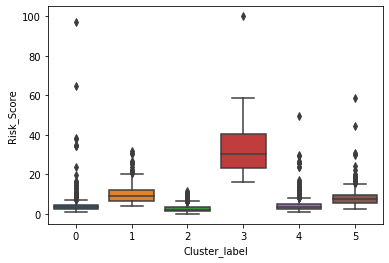

In [163]:
sns.boxplot(x="Cluster_label", y="Risk_Score", data=q4_2019)

In [164]:
#Save the clusters with risk scores
q4_2019.to_csv('/project_data/data_asset/2019q4_clusteredrisk.csv', index=False)

# Repeat with 2020 data?

## Q1 2020

In [165]:
df_quarter1_2020 = pd.read_csv('/project_data/data_asset/final_op_analysis_01012020_03312020.csv')
tmp = preprocessor_sprint1_regen.transformers[0][1].fit_transform(df_quarter1_2020[num_features])
df_quarter1_2020_processed = pd.DataFrame(data=tmp, columns=[c for c in num_features if df_quarter1_2020[c].isna().all()==False], index=df_quarter1_2020.index)
df_quarter1_2020_processed.head()

,Member Count,Count Script,Sum Dispensed Quantity,PR2,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,-0.483123,-0.364483,-0.278319,-0.710371,0.877724,0.059010,-0.151332,-0.261152,-0.180171,-0.112323,-0.04464,-0.245197,-0.050697,-0.224118,-0.190635,-0.202789,-0.075319,-0.343121,-0.068113,-0.015901,-0.729790,-0.255486,-0.077328
1,0.225641,0.088476,-0.056902,0.148788,-0.302954,-0.214233,-0.461664,-0.261152,-0.180171,-0.112323,-0.04464,-0.245197,-0.050697,-0.224118,-0.130599,-0.202789,-0.075319,-0.343121,-0.068113,-0.015901,0.367443,0.230096,-0.077328
2,5.954822,9.250602,8.264278,2.924651,7.583647,6.948279,0.158354,-0.206802,1.928368,1.802789,-0.04464,0.514448,-0.050697,0.400419,-0.093144,-0.202789,0.247885,0.640264,1.439753,-0.015901,1.344977,-0.088437,-0.077328
3,0.166578,0.088476,0.157433,0.313460,-0.223872,0.057332,-0.680394,-0.261152,-0.180171,-0.112323,-0.04464,1.495658,-0.050697,-0.224118,-0.110077,-0.202789,-0.075319,-0.343121,-0.068113,-0.015901,-0.135455,1.201260,-0.077328
4,-0.483123,-0.364483,-0.281399,-0.710371,0.877724,-0.182672,-0.151332,-0.261152,-0.180171,-0.112323,-0.04464,-0.245197,-0.050697,-0.224118,-0.177327,-0.202789,-0.075319,-0.343121,-0.068113,-0.015901,-0.729790,-0.255486,-0.077328


In [166]:
df_quarter1_2020_tfd = pca.transform(df_quarter1_2020_processed)
df_quarter1_2020_tfd_for_clustering = pd.DataFrame(data=df_quarter1_2020_tfd[:,:num_components_tokeep], 
                                              columns=[(f'Comp {c}') for c in range(1,num_components_tokeep+1)], 
                                              index=df_quarter1_2020_processed.index)
df_quarter1_2020_tfd_for_clustering.head()

,Comp 1,Comp 2,Comp 3,Comp 4,Comp 5
0,-0.361819,-0.896401,0.037254,0.228118,-0.322051
1,-0.186510,-0.228809,0.705722,0.041828,-0.192607
2,16.871037,-0.209141,1.088637,-0.784674,0.380990
3,0.139181,0.422983,0.962326,0.777580,0.584333
4,-0.457896,-0.881713,0.043479,0.230272,-0.304241


In [167]:
test_labels = kmeans.predict(df_quarter1_2020_tfd_for_clustering)
pd.Series(test_labels).value_counts()

2    8634
4    2650
0     699
5     640
1     575
3      41
dtype: int64

In [168]:
df_quarter1_2020['Cluster_label'] = pd.Series(test_labels, index=df_quarter1_2020.index)
print(list(df_quarter1_2020[df_quarter1_2020.Cluster_label == riskiest_cluster].PRSCRB_PROV_LOC_ID))

[103278, 105077, 105200, 100365, 101378, 101685, 115182, 116654, 117265, 1303, 121068, 122721, 132023, 153504, 153890, 153998, 154518, 137238, 139250, 139433, 147313, 170094, 171287, 175099, 155049, 157070, 157144, 157335, 157756, 164940, 165594, 166049, 16638, 167357, 169127, 17522, 178627, 179449, 2755, 28347, 4457]


In [169]:
#Risk Profile
riskscore_df = pd.read_csv('/project_data/data_asset/2020q1_riskscore.csv')
q1_2020 = pd.merge(df_quarter1_2020, riskscore_df, on='PRSCRB_PROV_LOC_ID')
q1_2020.groupby('Cluster_label').describe().reset_index()

Cluster_label Member Count                                             \
                       count        mean        std   min    25%    50%   
0             0        699.0    5.532189   9.230883   1.0    1.0    3.0   
1             1        575.0   58.838261  31.748521   1.0   37.0   52.0   
2             2       8634.0    6.912555   7.890665   1.0    2.0    4.0   
3             3         41.0  155.121951  48.115068  84.0  120.0  144.0   
4             4       2650.0    5.404528   6.629958   1.0    1.0    3.0   
5             5        640.0    5.415625   5.409295   1.0    2.0    3.0   

                Count Script                                               \
     75%    max        count        mean         std    min    25%    50%   
0    6.0   84.0        699.0    6.698140   11.481223    1.0    1.0    3.0   
1   72.0  195.0        575.0  147.761739   77.816325    1.0   96.5  129.0   
2    9.0   74.0       8634.0   11.986681   15.466054    1.0    2.0    6.0   
3  188.0  296.0         41.0  564.926829  245.920657  234.0  415.0  497.0   
4    7.0   66.0       2650.0    7.403396   10.540862    1.0    2.0    4.0   
5    7.0   27.0        640.0   18.260938   19.612818    1.0    5.0   11.0   

                 Sum Dispensed Quantity                                       \
     75%     max                  count          mean           std      min   
0    7.0    87.0                  699.0    200.854449    463.181167      1.2   
1  177.0   490.0                  575.0   7969.908085   5224.922179    192.0   
2   15.0   101.0                 8634.0    516.285872    827.667215      0.5   
3  643.0  1534.0                   41.0  41784.073171  20076.123314  20507.0   
4    9.0   112.0                 2650.0    241.704151    458.762069      1.0   
5   24.0    90.0                  640.0   1086.675000   1335.173709      2.0   

                                         PRSCRB_PROV_LOC_ID                 \
        25%      50%       75%       max              count           mean   
0     21.50     60.0    176.50    6423.0              699.0  118209.384835   
1   4894.50   6497.0  10051.50   29236.0              575.0  117202.474783   
2     46.00    166.0    581.75    5771.0             8634.0  118365.206393   
3  29303.00  36941.0  49939.00  134140.0               41.0  124000.951220   
4     30.00     83.0    230.00    5157.0             2650.0  121758.252075   
5    174.25    540.0   1464.00    7867.0              640.0  112243.671875   

                                                                  Total Days  \
            std     min        25%       50%        75%       max      count   
0  42004.912694   176.0  109034.00  122879.0  140265.00  179753.0      699.0   
1  45254.400785   297.0  107561.50  124114.0  144714.50  179784.0      575.0   
2  44168.176950    13.0  106885.25  122150.5  148402.75  182198.0     8634.0   
3  52757.126103  1303.0  105077.00  139433.0  157756.00  179449.0       41.0   
4  42714.909177    12.0  108834.00  123298.5  151930.50  180564.0     2650.0   
5  47241.687550   219.0  104998.00  119907.0  141293.50  179247.0      640.0   

                                                           PR2            \
        mean        std   min    25%   50%   75%   max   count      mean   
0  34.675250  30.025617   1.0   1.00  33.0  62.0  90.0   699.0  1.162313   
1  86.737391  14.569750   1.0  89.00  90.0  90.0  91.0   575.0  2.630594   
2  52.422516  32.605773   1.0  21.00  64.0  81.0  91.0  8634.0  1.579637   
3  89.048780   7.409289  44.0  90.00  90.0  91.0  91.0    41.0  3.621141   
4  42.109811  31.959434   1.0   2.00  48.0  71.0  91.0  2650.0  1.281663   
5  64.362500  27.933464   1.0  52.75  75.0  86.0  91.0   640.0  3.360492   

                                                                PR1  \
        std    min       25%       50%       75%        max   count   
0  0.382269  1.000  1.000000  1.000000  1.118056   4.285714   699.0   
1  0.860875  1.000  2.166667  2.555556  3.021139   7.50

In [170]:
#If we consider the risk score to be 50+ for bad and medium risk actors, we need to find the clusters for the following actors.
bad_actors = list(riskscore_df[riskscore_df.Risk_Score > 50].PRSCRB_PROV_LOC_ID)
bad_actors

[101951, 126953, 139433, 148485, 170094, 16638, 17522, 175614]

In [171]:
#Which cluster do the risk score based bad actors belong to
print(q1_2020[q1_2020.PRSCRB_PROV_LOC_ID.isin(bad_actors)][["PRSCRB_PROV_LOC_ID","Cluster_label","Risk_Score"]])

       PRSCRB_PROV_LOC_ID  Cluster_label  Risk_Score
1397               101951              0   72.276897
4320               126953              0   58.550551
8161               139433              3   55.045017
8970               148485              0   76.270753
9304               170094              3   57.640587
11280               16638              3  100.000000
11608               17522              3   73.379168
11672              175614              0   60.633173


In [172]:
#Least risk actors identified in riskiest cluster
q1_2020[(q1_2020.Cluster_label == riskiest_cluster) & (q1_2020.Risk_Score < 20)][["PRSCRB_PROV_LOC_ID","Cluster_label","Risk_Score"]]

,PRSCRB_PROV_LOC_ID,Cluster_label,Risk_Score
1322,101685,3,17.475378
3872,115182,3,19.720226
11243,166049,3,19.844854


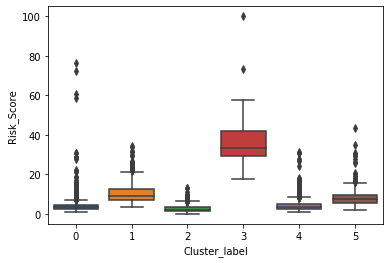

In [173]:
sns.boxplot(x="Cluster_label", y="Risk_Score", data=q1_2020)

In [174]:
#Save the clusters with risk scores
q1_2020.to_csv('/project_data/data_asset/2020q1_clusteredrisk.csv', index=False)

## Q2 2020

In [175]:
df_quarter2_2020 = pd.read_csv('/project_data/data_asset/final_op_analysis_04012020_06302020.csv')
tmp = preprocessor_sprint1_regen.transformers[0][1].fit_transform(df_quarter2_2020[num_features])
df_quarter2_2020_processed = pd.DataFrame(data=tmp, columns=[c for c in num_features if df_quarter2_2020[c].isna().all()==False], index=df_quarter2_2020.index)
df_quarter2_2020_processed.head()

,Member Count,Count Script,Sum Dispensed Quantity,PR2,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,-0.359143,-0.272772,-0.243982,0.036755,-0.448845,-0.329019,0.399970,1.769841,-0.176465,-0.112155,-0.03679,-0.248761,-0.046667,-0.240754,-0.151281,-0.19523,-0.072993,-0.351752,-0.065766,-0.015662,-0.706418,-0.203609,-0.06903
1,0.936621,1.115710,0.501466,1.462783,0.571643,0.277220,-0.500768,-0.249041,-0.176465,1.241387,-0.03679,1.044907,-0.046667,1.683518,-0.126756,-0.19523,-0.072993,0.235899,-0.065766,-0.015662,-0.557586,1.074101,-0.06903
2,-0.297440,-0.251735,-0.237015,-0.147249,-0.465574,-0.333630,0.712899,-0.249041,-0.176465,-0.112155,-0.03679,-0.248761,-0.046667,-0.240754,0.229029,-0.19523,-0.072993,1.411202,-0.065766,-0.015662,-0.706418,-0.203609,-0.06903
3,-0.174034,-0.209659,-0.168256,-0.331252,-0.576616,-0.317798,-0.495439,-0.249041,-0.176465,-0.112155,-0.03679,-0.248761,-0.046667,-0.240754,-0.211625,-0.19523,-0.072993,-0.351752,-0.065766,-0.015662,-0.706418,-0.203609,-0.06903
4,-0.482549,-0.356923,-0.273970,-0.699259,0.901689,-0.178378,-0.328334,-0.249041,-0.176465,-0.112155,-0.03679,-0.248761,-0.046667,-0.240754,-0.211923,-0.19523,-0.072993,-0.351752,-0.065766,-0.015662,-0.706418,-0.203609,-0.06903


In [176]:
df_quarter2_2020_tfd = pca.transform(df_quarter2_2020_processed)
df_quarter2_2020_tfd_for_clustering = pd.DataFrame(data=df_quarter2_2020_tfd[:,:num_components_tokeep], 
                                              columns=[(f'Comp {c}') for c in range(1,num_components_tokeep+1)], 
                                              index=df_quarter2_2020_processed.index)
df_quarter2_2020_tfd_for_clustering.head()

,Comp 1,Comp 2,Comp 3,Comp 4,Comp 5
0,-0.782294,0.089502,-0.797433,0.547267,-0.382131
1,1.739752,1.560080,0.400792,0.842255,0.695633
2,-0.681313,0.275279,-0.750873,0.071972,-0.048700
3,-0.752102,-0.555775,0.387794,0.593620,-0.207265
4,-0.442509,-0.886299,0.159555,0.256619,-0.322350


In [177]:
test_labels = kmeans.predict(df_quarter2_2020_tfd_for_clustering)
pd.Series(test_labels).value_counts()

2    8268
4    2496
0     643
5     604
1     512
3      40
dtype: int64

In [178]:
df_quarter2_2020['Cluster_label'] = pd.Series(test_labels, index=df_quarter2_2020.index)
print(list(df_quarter2_2020[df_quarter2_2020.Cluster_label == riskiest_cluster].PRSCRB_PROV_LOC_ID))

[105200, 106590, 100365, 100669, 101378, 115182, 117265, 122721, 124315, 121068, 153791, 153890, 153998, 154518, 155049, 157070, 157144, 157335, 157756, 139250, 139433, 147313, 167357, 170094, 171287, 172819, 179449, 179776, 175099, 17522, 178627, 164940, 165594, 166049, 16638, 166436, 2755, 28347, 4457, 7168]


In [179]:
#Risk Profile
riskscore_df = pd.read_csv('/project_data/data_asset/2020q1_riskscore.csv')
q2_2020 = pd.merge(df_quarter2_2020, riskscore_df, on='PRSCRB_PROV_LOC_ID')
q2_2020.groupby('Cluster_label').describe().reset_index()

Cluster_label Member Count                                             \
                       count        mean        std   min    25%    50%   
0             0        478.0    5.751046   8.663204   1.0    1.0    3.0   
1             1        500.0   56.510000  30.780591   1.0   36.0   50.0   
2             2       7216.0    7.550028   8.053769   1.0    2.0    5.0   
3             3         40.0  151.725000  52.514217  87.0  121.0  137.5   
4             4       2040.0    5.905392   6.753734   1.0    2.0    4.0   
5             5        538.0    6.078067   5.512255   1.0    2.0    4.0   

                 Count Script                                               \
      75%    max        count        mean         std    min    25%    50%   
0    6.00   85.0        478.0    7.104603   11.001503    1.0    2.0    4.0   
1   68.25  201.0        500.0  144.202000   74.783222    1.0   94.0  125.5   
2   10.00   77.0       7216.0   13.075527   15.609954    1.0    3.0    7.0   
3  169.25  292.0         40.0  571.550000  235.648037  322.0  411.0  528.5   
4    7.00   68.0       2040.0    8.178431   10.949056    1.0    2.0    5.0   
5    9.00   25.0        538.0   20.706320   20.058740    1.0    6.0   13.0   

                  Sum Dispensed Quantity                                       \
      75%     max                  count          mean           std      min   
0    7.75    97.0                  478.0    220.838180    500.945567      1.0   
1  174.00   456.0                  500.0   8112.132500   5378.873698    160.0   
2   17.00    98.0                 7216.0    579.462314    858.341848      1.0   
3  615.00  1429.0                   40.0  42945.187500  19931.285873  19710.0   
4   10.00   105.0                 2040.0    270.637990    501.765123      1.0   
5   31.00   144.0                  538.0   1290.370260   1402.390555      2.0   

                                          PRSCRB_PROV_LOC_ID                 \
        25%      50%       75%        max              count           mean   
0     30.00     78.0    206.75    5259.00              478.0  122496.836820   
1   4809.75   6371.0   9988.75   28468.00              500.0  117790.092000   
2     65.00    210.0    716.25    7690.25             7216.0  118082.956901   
3  29503.00  37875.5  49933.50  125456.50               40.0  126892.850000   
4     38.00     98.5    259.25    4432.00             2040.0  121411.932843   
5    281.00    786.0   1891.00   10050.00              538.0  112694.059480   

                                                                  Total Days  \
            std     min        25%       50%        75%       max      count   
0  39709.770996   459.0  110060.75  124901.5  147707.25  179753.0      478.0   
1  45879.043721   297.0  107227.75  124136.0  145408.50  180255.0      500.0   
2  43874.385084    13.0  106790.50  121959.0  148040.75  182198.0     7216.0   
3  54098.002598  2755.0  106242.50  153840.5  165707.75  179776.0       40.0   
4  40799.281582    12.0  108524.25  121837.5  149555.25  180615.0     2040.0   
5  47593.185631   772.0  104670.00  119266.5  141576.75  179994.0      538.0   

                                                            PR2            \
        mean        std   min    25%   50%    75%   max   count      mean   
0  38.016736  30.524619   1.0   1.25  37.5  64.75  91.0   478.0  1.211412   
1  88.296000  12.504123   1.0  90.00  91.0  91.00  91.0   500.0  2.679435   
2  58.064440  30.350978   1.0  37.00  69.0  84.00  91.0  7216.0  1.626814   
3  90.825000   0.675107  87.0  91.00  91.0  91.00  91.0    40.0  3.793076   
4  47.339216  31.078830   1.0  18.75  53.0  76.00  91.0  2040.0  1.318204   
5  69.726766  26.118582   1.0  62.00  81.0  88.00  91.0   538.0  3.517934   

                                                                   PR1  \
        std       min       25%       50%       75%        max   count   
0  0.477691  1.000000  1.000000  1.000000  1.222222   5.000000   478.0   
1  0.837612  1

In [180]:
#If we consider the risk score to be 50+ for bad and medium risk actors, we need to find the clusters for the following actors.
bad_actors = list(riskscore_df[riskscore_df.Risk_Score > 50].PRSCRB_PROV_LOC_ID)
bad_actors

[101951, 126953, 139433, 148485, 170094, 16638, 17522, 175614]

In [181]:
#Which cluster do the risk score based bad actors belong to
# q2 - [117265, 16638, 155049, 157335, 170094, 17522]
print(q2_2020[q2_2020.PRSCRB_PROV_LOC_ID.isin(bad_actors)][["PRSCRB_PROV_LOC_ID","Cluster_label","Risk_Score"]])

      PRSCRB_PROV_LOC_ID  Cluster_label  Risk_Score
1226              101951              0   72.276897
4391              126953              0   58.550551
5935              148485              0   76.270753
7616              139433              3   55.045017
8461              170094              3   57.640587
9082               17522              3   73.379168
9128              175614              0   60.633173
9960               16638              3  100.000000


In [182]:
#Least risk actors identified in riskiest cluster
q2_2020[(q2_2020.Cluster_label == riskiest_cluster) & (q2_2020.Risk_Score < 20)][["PRSCRB_PROV_LOC_ID","Cluster_label","Risk_Score"]]

,PRSCRB_PROV_LOC_ID,Cluster_label,Risk_Score
797,106590,3,5.088624
1810,115182,3,19.720226
6355,153791,3,17.442703
8820,179776,3,6.211749
9927,166049,3,19.844854
10664,7168,3,17.408098


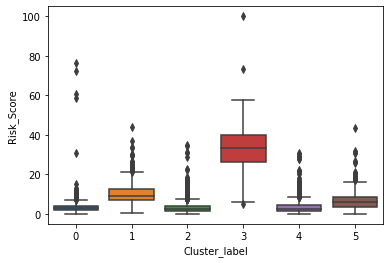

In [183]:
sns.boxplot(x="Cluster_label", y="Risk_Score", data=q2_2020)

In [184]:
#Save the clusters with risk scores
q2_2020.to_csv('/project_data/data_asset/2020q2_clusteredrisk.csv', index=False)

In [185]:
list(set(list(df_quarter2_2020[df_quarter2_2020.Cluster_label == riskiest_cluster].PRSCRB_PROV_LOC_ID)) & 
     set(list(df_quarter1_2020[df_quarter1_2020.Cluster_label == riskiest_cluster].PRSCRB_PROV_LOC_ID)))
#32 are common in Q1 and Q2 2020

[101378,
 100365,
 157070,
 153998,
 117265,
 154518,
 157335,
 171287,
 166049,
 153890,
 155049,
 139433,
 28347,
 157756,
 167357,
 178627,
 2755,
 164940,
 157144,
 165594,
 122721,
 4457,
 121068,
 115182,
 170094,
 105200,
 147313,
 139250,
 17522,
 179449,
 175099,
 16638]

Todo - once done with presentation
# 6. Observe the difference in risk score trends for bad actors identified by risk scores but not by Clustering
##### This does not affect the outcome of the clusters, but is more of a general view to gauge the cause of difference between the two models